# Farm use case LLM scalability

In [1]:
%cd ..

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [25]:
%pwd  # should be "llm-adaptation"

'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

## Run the experiment

In [3]:
import subprocess

def run(llm_config, scale_config):
    configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml", "farm/configs/strategy_multiple.yaml", "configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]
    run = ["python", "main.py", *configs, "-e", "1", "-s", "1"]
    # run += ["--extra_config", "{\"steps\": 30}"]

    result = subprocess.run(run, capture_output=False)
    # result = subprocess.run(run, capture_output=True)
    # stdout = result.stdout.decode("utf-8")
    # print(stdout.partition("Simulation done")[2])

    # stderr = result.stderr.decode("utf-8")
    # if (stderr):
    #     print(stderr)

### GPT-4o mini

In [4]:
run("llm_gpt4omini", "scale1")


Traceback (most recent call last):
  File "C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\main.py", line 8, in <module>
    from utils import nested_update, read_configs, Logger, print_config
  File "C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation\utils.py", line 8, in <module>
    from langchain_core.messages import AIMessage
ModuleNotFoundError: No module named 'langchain_core'



## Results

In [48]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
sns.set_theme()

In [49]:
results_folder = Path("./logs/no_battery/scale")

In [50]:
results_files = sorted(results_folder.glob("*/*.llm.csv"))
print(len(results_files), "files found")

4 files found


In [51]:
datas = []

In [52]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        data = pd.read_csv(file)
        stats_file = file.parent / name.replace(".llm", ".csv")
        stats = pd.read_csv(stats_file)
        damage = stats.iloc[299]["damage"]

        parts = name.split("_")
        llm = parts[2]
        scale = parts[-1].split(".")[0]
        params = parts[3:-1]
        params = ",\n".join(params)

        data["llm"] = llm
        data["scale"] = scale
        data["params"] = params
        data["damage"] = damage

        # counts of drones in state
        steps = stats[stats["step"].isin(data["step"])]
        data["protecting"] = np.nan
        data["idle"] = np.nan
        data["moving_to_field"] = np.nan
        mask = data["try"] == 0
        data.loc[mask, "protecting"] = steps["PROTECTING"].values
        data.loc[mask, "idle"] = steps["IDLE"].values
        data.loc[mask, "moving_to_field"] = steps["MOVING_TO_FIELD"].values

        datas.append(data)

    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

C:\Users\micha\AppData\Local\Temp\ipykernel_29916\4086462048.py:9: DtypeWarning: Columns (37,40,43,52,55,58,61,79,82,157,160,163,250,253,298,577,655) have mixed types. Specify dtype option on import or set low_memory=False.
  stats = pd.read_csv(stats_file)


In [53]:
summary = pd.concat(datas, ignore_index=True)
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params,damage,protecting,idle,moving_to_field
0,1,0,0,1214,457,0,8.698162,sd2,scale1,"strategy,\nretry2",155,0.0,4.0,4.0
1,11,0,0,1252,380,0,8.075552,sd2,scale1,"strategy,\nretry2",155,3.0,4.0,1.0
2,21,0,0,1250,410,0,7.744268,sd2,scale1,"strategy,\nretry2",155,4.0,2.0,2.0
3,31,0,0,1270,558,0,14.144804,sd2,scale1,"strategy,\nretry2",155,6.0,0.0,2.0
4,41,0,0,1286,451,0,9.783066,sd2,scale1,"strategy,\nretry2",155,7.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,271,0,0,30947,3204,0,67.863197,sd2,scale57,"strategyMultiple,\nretry2",4689,15.0,411.0,11.0
144,281,0,11,31075,3056,0,47.499207,sd2,scale57,"strategyMultiple,\nretry2",4689,16.0,409.0,12.0
145,281,1,0,34406,2789,0,42.716601,sd2,scale57,"strategyMultiple,\nretry2",4689,NaN,NaN,NaN
146,291,0,1,30915,1888,0,31.332952,sd2,scale57,"strategyMultiple,\nretry2",4689,16.0,406.0,15.0


In [54]:
summary['scale'] = summary['scale'].map({
    "scale1": 1,
    "scale10": 5,
    "scale20": 10,
    "scale57": 25,
    "scale116": 50,
    "scale206": 90,
})

In [55]:
summary.to_csv(results_folder / "summary.csv", index=False)

In [56]:
initial = summary[summary["try"] == 0]
initial

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,scale,params,damage,protecting,idle,moving_to_field
0,1,0,0,1214,457,0,8.698162,sd2,1,"strategy,\nretry2",155,0.0,4.0,4.0
1,11,0,0,1252,380,0,8.075552,sd2,1,"strategy,\nretry2",155,3.0,4.0,1.0
2,21,0,0,1250,410,0,7.744268,sd2,1,"strategy,\nretry2",155,4.0,2.0,2.0
3,31,0,0,1270,558,0,14.144804,sd2,1,"strategy,\nretry2",155,6.0,0.0,2.0
4,41,0,0,1286,451,0,9.783066,sd2,1,"strategy,\nretry2",155,7.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,251,0,11,30980,3109,0,57.419020,sd2,25,"strategyMultiple,\nretry2",4689,15.0,411.0,11.0
142,261,0,0,30947,3129,0,47.222040,sd2,25,"strategyMultiple,\nretry2",4689,15.0,411.0,11.0
143,271,0,0,30947,3204,0,67.863197,sd2,25,"strategyMultiple,\nretry2",4689,15.0,411.0,11.0
144,281,0,11,31075,3056,0,47.499207,sd2,25,"strategyMultiple,\nretry2",4689,16.0,409.0,12.0


### Errors

In [57]:
repeated = pd.DataFrame(columns=["llm", "scale", "try", "error_count"])
for llm in summary["llm"].unique():
    for scale in summary["scale"].unique():
        for retry in (1, 2):
            count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)])
            repeated.loc[len(repeated)] = [llm, scale, retry, count]
repeated

,llm,scale,try,error_count
0,sd2,1,1,0
1,sd2,1,2,0
2,sd2,5,1,2
3,sd2,5,2,1
4,sd2,10,1,6
5,sd2,10,2,1
6,sd2,25,1,14
7,sd2,25,2,4


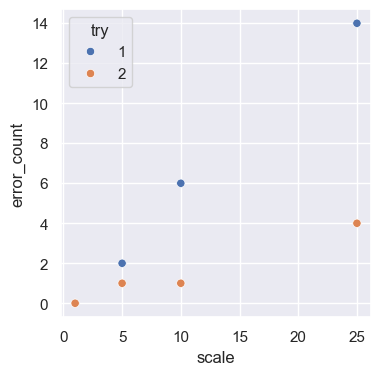

In [74]:
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x="scale", y="error_count", hue="try", data=repeated, ax=ax, palette="deep")
plt.show()

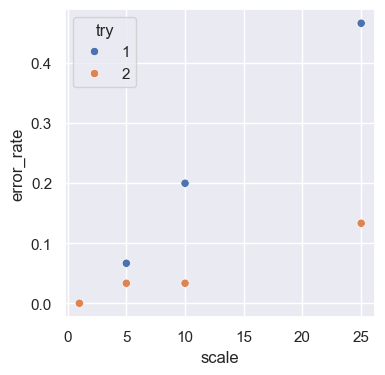

In [73]:
repeated["error_rate"] = repeated["error_count"] / 30.0
fig, ax = plt.subplots(figsize=(4, 4))
sns.scatterplot(x="scale", y="error_rate", hue="try", data=repeated, ax=ax, palette="deep")
plt.show()

### Time

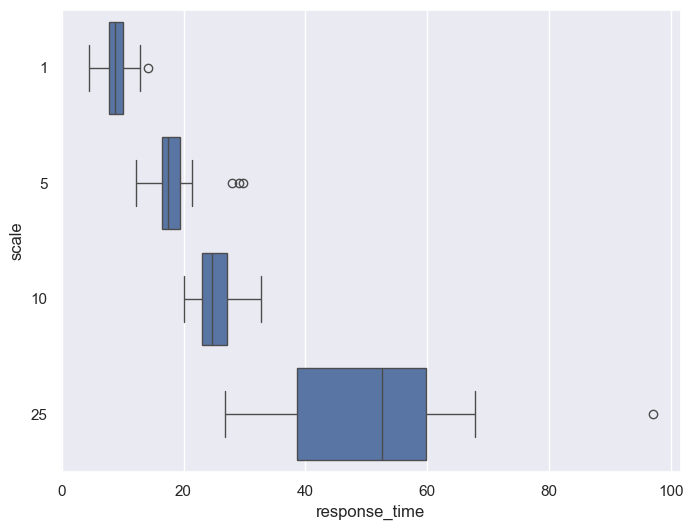

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="response_time", y="scale", data=initial, ax=ax, orient="h")
plt.show()

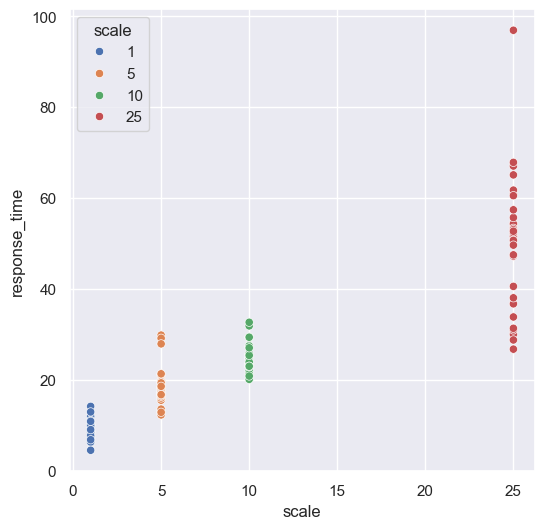

In [78]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

### Input tokens

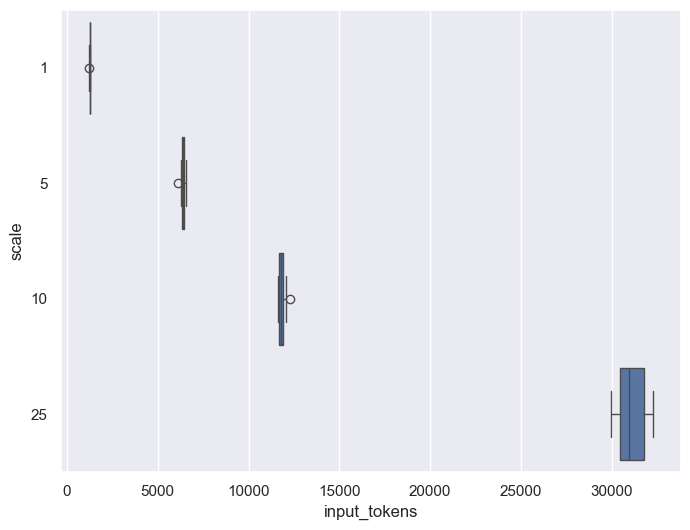

In [60]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="input_tokens", y="scale", data=initial, ax=ax, orient="h")
plt.show()

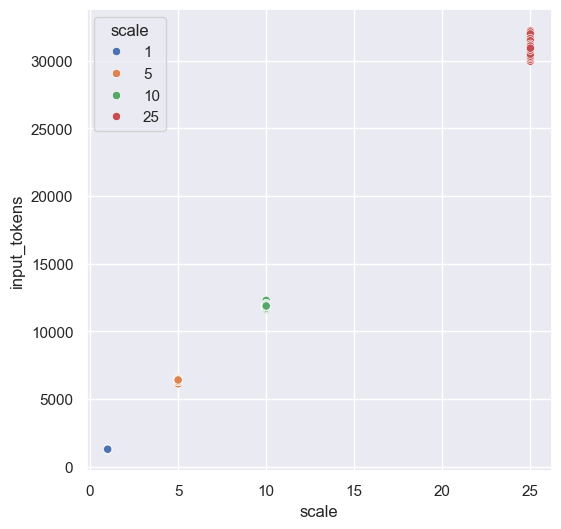

In [79]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="input_tokens", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

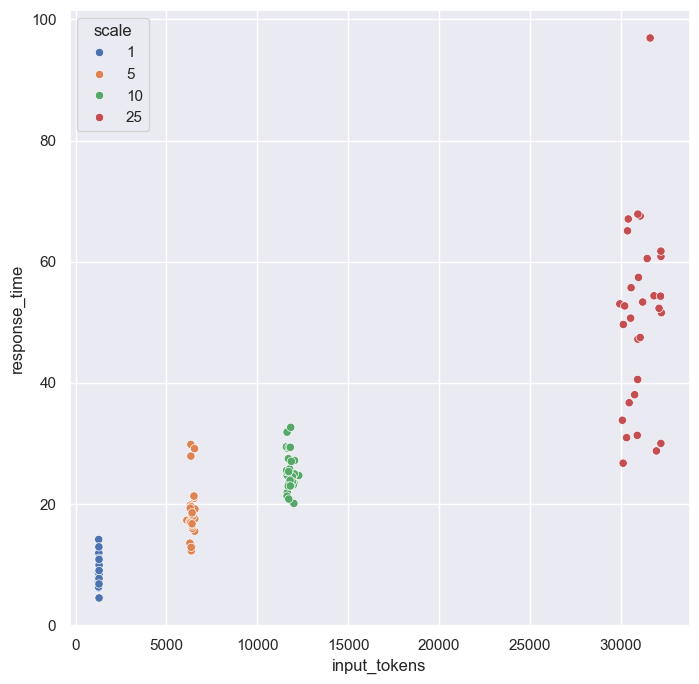

In [69]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="input_tokens", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

### Output tokens

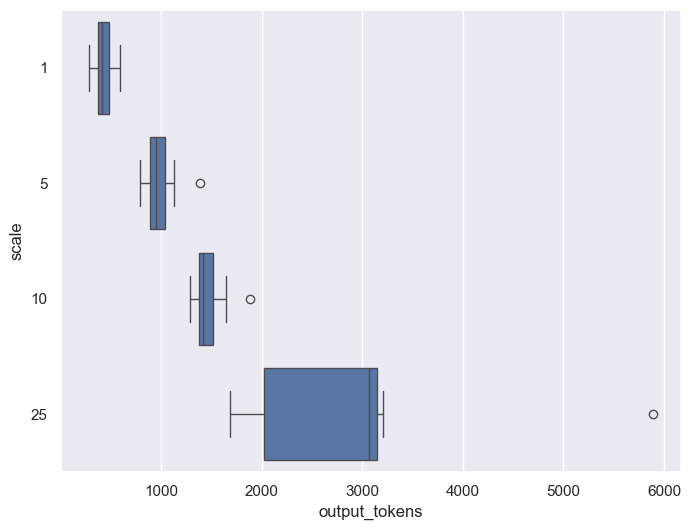

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="output_tokens", y="scale", data=initial, ax=ax, orient="h")
plt.show()

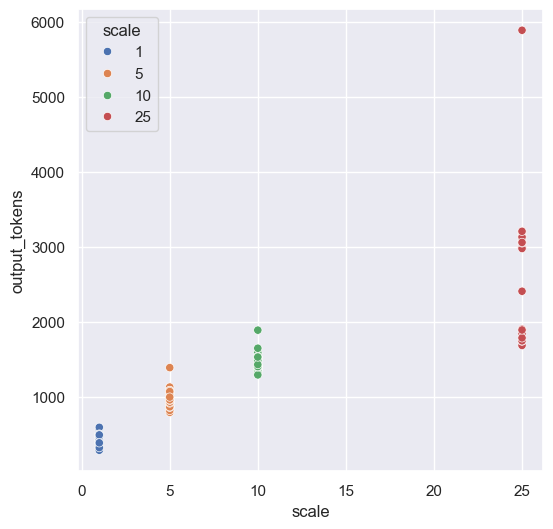

In [80]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="output_tokens", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

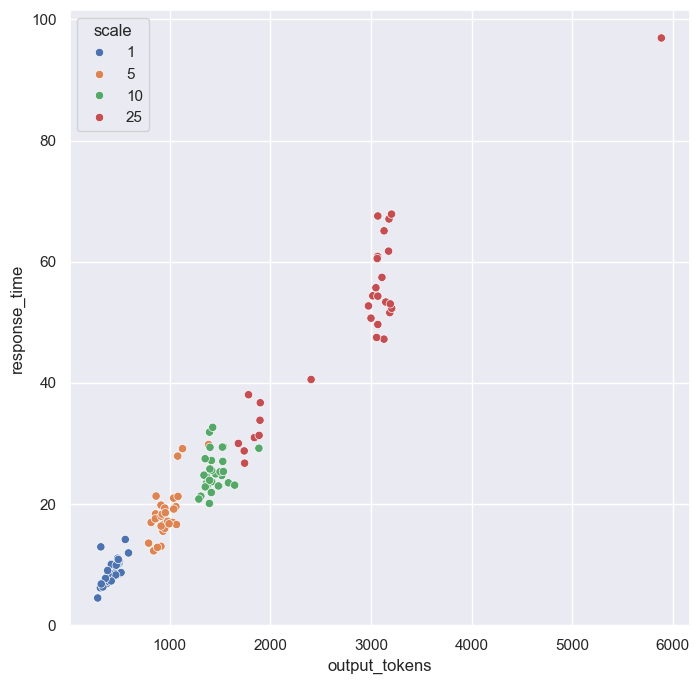

In [70]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

### Drone states

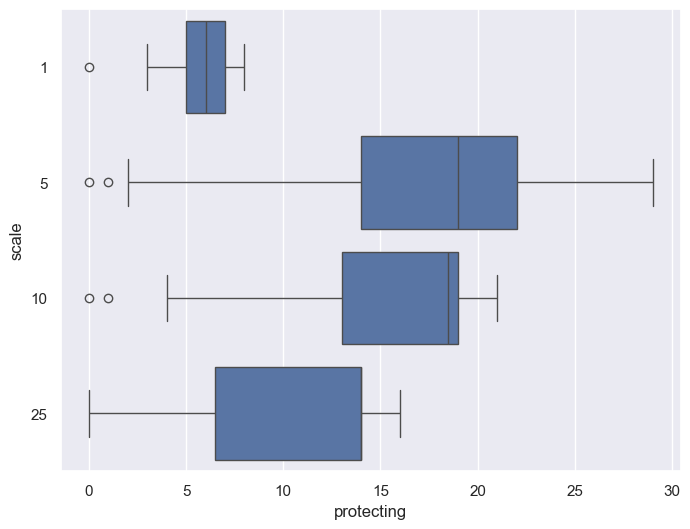

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="protecting", y="scale", data=initial, ax=ax, orient="h")
plt.show()

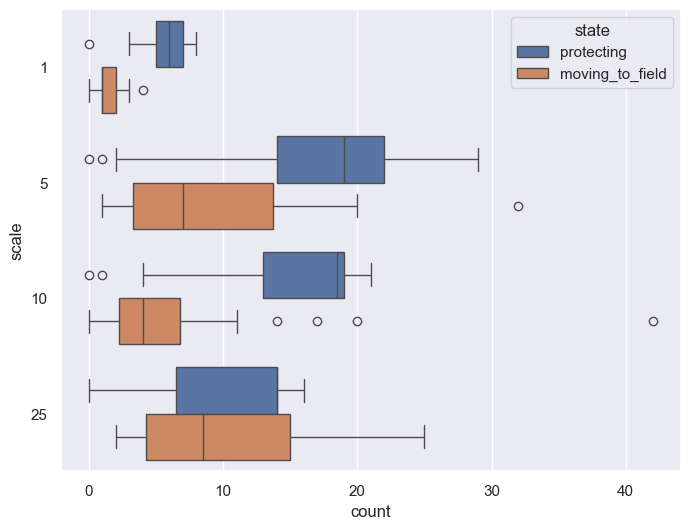

In [65]:
melted = pd.melt(
    initial,
    id_vars=["scale"],
    value_vars=["protecting", "moving_to_field"],
    var_name="state",
    value_name="count"
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="count", y="scale", hue="state", data=melted, orient="h", ax=ax)
plt.show()

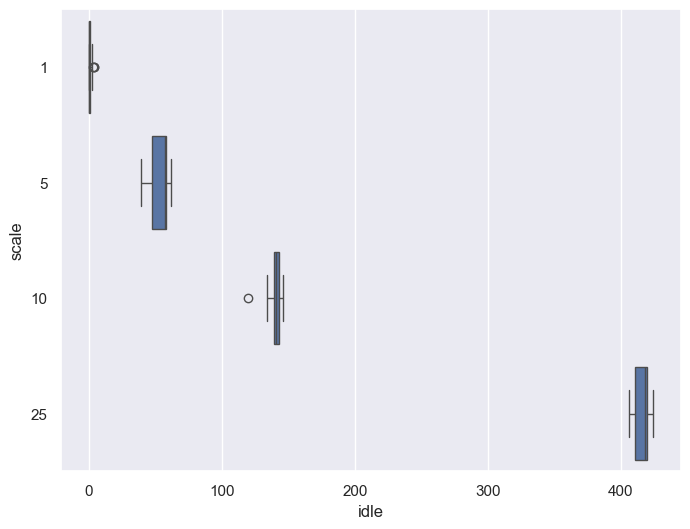

In [66]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="idle", y="scale", data=initial, ax=ax, orient="h")
plt.show()

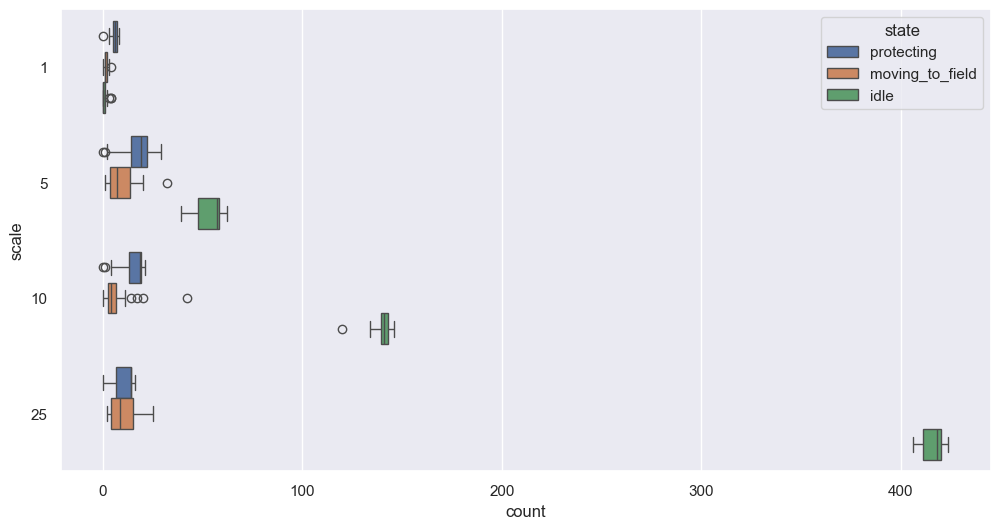

In [82]:
melted = pd.melt(
    initial,
    id_vars=["scale"],
    value_vars=["protecting", "moving_to_field", "idle"],
    var_name="state",
    value_name="count"
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x="count", y="scale", hue="state", data=melted, orient="h", ax=ax)
plt.show()

### Damage

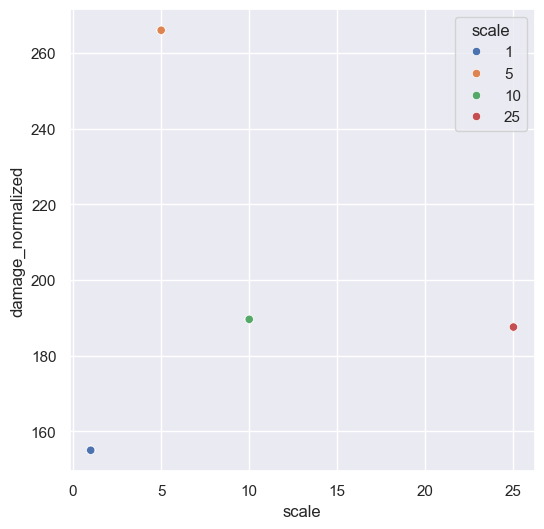

In [87]:
initial.loc[:,"damage_normalized"] = (initial["damage"] / initial["scale"])
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="damage_normalized", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()